In [1]:
from sklearn.metrics import confusion_matrix #, confusion_matrix_at_thresholds, roc_curve
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from useful_functions_global import *
import gc

In [2]:
class DataFrame():
    def __init__(self, survey, data, field, qual_cuts_dict={}):
        self.survey = survey
        self.data = data
        self.field = field
        self.quality_cuts = qual_cuts_dict
        
        ## coordinates
        self.ra_limits = (data['coord_ra'].min(), data['coord_ra'].max())
        self.dec_limits = (data['coord_dec'].min(), data['coord_dec'].max())
        self.rubin_ra = data['coord_ra']
        self.rubin_dec = data['coord_dec']
        self.euclid_ra = data['RIGHT_ASCENSION']
        self.euclid_dec = data['DECLINATION']

        ## Euclid bands (flux given in mu_Jy)
        num = 2 #as suggested in Zerjal et al
        self.VIS_mag = flux2mag(data[f'FLUX_VIS_{num}FWHM_APER']*(10**3)) #convert to nJy
        self.H_mag = flux2mag(data[f'FLUX_H_{num}FWHM_APER']*(10**3)) #convert to nJy
        self.Y_mag = flux2mag(data[f'FLUX_Y_{num}FWHM_APER']*(10**3)) #convert to nJy
        self.J_mag = flux2mag(data[f'FLUX_J_{num}FWHM_APER']*(10**3)) #convert to nJy
        self.VIS_magerr = fluxerr2magerr(self.VIS_mag, flux2mag(data[f'FLUXERR_VIS_{num}FWHM_APER']*(10**3)))
        self.H_magerr = fluxerr2magerr(self.H_mag, flux2mag(data[f'FLUXERR_H_{num}FWHM_APER']*(10**3)))
        self.Y_magerr = fluxerr2magerr(self.Y_mag, flux2mag(data[f'FLUXERR_Y_{num}FWHM_APER']*(10**3)))
        self.J_magerr = fluxerr2magerr(self.J_mag, flux2mag(data[f'FLUXERR_J_{num}FWHM_APER']*(10**3)))

        ## Rubin bands
        self.g_mag = flux2mag(data['g_psfFlux'])
        self.r_mag = flux2mag(data['r_psfFlux'])
        self.i_mag = flux2mag(data['i_psfFlux'])
        self.z_mag = flux2mag(data['z_psfFlux'])
        self.g_magerr = fluxerr2magerr(self.g_mag, flux2mag(data['g_psfFluxErr']))
        self.r_magerr = fluxerr2magerr(self.r_mag, flux2mag(data['r_psfFluxErr']))
        self.i_magerr = fluxerr2magerr(self.i_mag, flux2mag(data['i_psfFluxErr']))
        self.z_magerr = fluxerr2magerr(self.z_mag, flux2mag(data['z_psfFluxErr']))

        self.pointlikeprob = data['POINT_LIKE_PROB']
        self.ellipticity = data['ELLIPTICITY']
        self.mumax_minus_mag = self.data['MUMAX_MINUS_MAG']

    def Zerjal_cut(self):
        stars_mask = (self.ellipticity < 0.2) 
        stars_mask &= (self.mumax_minus_mag< -2.7) & (self.mumax_minus_mag> -3.25)
        return stars_mask, self.apply_mask(stars_mask)

    def POINT_LIKE_PROB_cut(self, threshold):
        stars_mask = (self.pointlikeprob > threshold)
        return stars_mask, self.apply_mask(stars_mask)

    def POINT_LIKE_FLAG_cut(self):
        stars_mask = (self.data['POINT_LIKE_FLAG'] == 1)
        return stars_mask, self.apply_mask(stars_mask)

    def apply_mask(self, mask):
        ## takes in a mask, applies it to the df, then returns another DataFrame object
        new_data = self.data[mask]
        return DataFrame(self.survey, new_data, self.field, self.quality_cuts)
        
    def clean_data(self, lsst_bands, euclid_bands, lsst_sn_bands, euclid_sn_bands, snr=5, flags = True, det_qual_flags = [0, 2]):
        '''
        inputs
        --------
        lsst_bands : str, bands (from ugrizy) in which to enforce quality flags
        euclid_bands : list of str, bands (from VIS, Y, J, H) in which to enforce quality flags
        lsst_sn_bands : str, bands (from ugrizy) in which to enforce source to noise cuts
        euclid_sn_bands : list of str, bands (from VIS, Y, J, H) in which to enforce source to noise cuts
        snr : the source to noise ratio you want to enforce

        returns
        --------
        new DataFrame object but with the cuts applied and an updated dictionary to keep track
        '''
        df = self.data
        ## 1. flags
        if flags == True:
            mask = (df['detect_isIsolated'] == True) #lsst
            mask &= (df['SPURIOUS_FLAG'] == 0) #euclid
            det_qual_mask = (df['DET_QUALITY_FLAG'] == 0)
            for i in det_qual_flags:
                if i == 0:
                    pass
                else:
                    det_qual_mask |= (df['DET_QUALITY_FLAG'] == i)
            mask &= det_qual_mask
        ## 2. per band S/N
        for band in lsst_sn_bands:
            mask &= (df[f'{band}_psfFlux']/df[f'{band}_psfFluxErr'] > snr)
        for band in euclid_sn_bands:
                #if band == 'VIS':
            #    mask &= (merged_df[f'FLUX_VIS_PSF']/merged_df[f'FLUXERR_VIS_PSF'] > snr)
            #else:
            ## I actually don't know which one to use for VIS
            num = 2
            mask &= (df[f'FLUX_{band}_{num}FWHM_APER']/df[f'FLUXERR_{band}_{num}FWHM_APER'] > snr)
        ## 3. per band flag
        for band in lsst_bands:
            mask &= (df[f'{band}_psfFlux_flag'] == 0)
            
        ## see https://euclid.esac.esa.int/dr/q1/dpdd/merdpd/merphotometrycookbook.html abt which flags to enforce
        #for band in euclid_bands:
        #    mask &= (merged_df[f'FLAG_{band}']==0)
        
        ## 4. enforcing that euclid sources having FWHM above 1.5" is spurious (Zerjal et al. suggestion)
        f = 1.5
        mask &= (df['FWHM'] <= f)

        ## updates the quality_cuts attribute along the way, so I can keep track of these things
        cut_dict = {'detect_isIsolated' : True, 'SPURIOUS_FLAG' : 0, 'DET_QUALITY_FLAG' : det_qual_flags, 
                    'LSST S/N' : f'{lsst_sn_bands} > {snr} ', 'Euclid S/N' : f'{euclid_sn_bands} > {snr} ', 
                    'LSST per band flag' : lsst_bands, 'FWHM' : f}
        if len(self.quality_cuts.keys()) != 0:
            for key in self.quality_cuts.keys():
                cut_dict[key] = cut_dict[key] + self.quality_cuts[key]

        return DataFrame(self.survey, df[mask], self.field, cut_dict)

In [3]:
survey = 'dp2'

files = Path('.').glob(f'euclid_data/q1/*_{survey}_euclid_merged.parquet')
ecdfs_list = []
edfs_list = []
for file in files:
    with open(file, 'rb') as f:
        df = pd.read_parquet(f, engine='fastparquet')
    file = str(file)
    parquet = file[(file.rfind('/')+1):]
    tract = int(parquet[0:parquet.find('_')])
    field = get_field(tract)
    if field == 'EDFS':
        edfs_list.append(df)
    elif field == 'ECDFS':
        ecdfs_list.append(df)
ecdfs = pd.concat(ecdfs_list, ignore_index=True)
edfs = pd.concat(edfs_list, ignore_index=True)

In [4]:
EDFS = DataFrame('dp2',edfs,'EDFS')
ECDFS = DataFrame('dp2',ecdfs,'ECDFS')

del ecdfs, edfs, ecdfs_list, edfs_list
gc.collect()

37

In [5]:
## euclid truth only valid to 25 mag
maglim = 25
mag_validity_mask = (ECDFS.i_mag<maglim)
DF_magcut = ECDFS.apply_mask(mag_validity_mask)

In [6]:
def lsst_predicted(DF, threshold):
    ## this will eventually be generalized to more classifier
    probability = 1 - DF.data['i_model_extendedness'] # 0 = gal, 1 = star. star is positive
    #probability is like lsst "point like probability"
    mask = probability.notna()
    prediction = (probability[mask] >= threshold).astype(int)
    #drop NaNs appearing in the lsst class, use mask to drop same from euclid
    return prediction, mask

def euclid_truth(DF):
    ## define the truth labels (star = 1 = true = positive)
    euclidtruth = np.zeros_like(DF.data['i_model_extendedness'])
    ## will change euclid truth eventually and need to generalize, start with POINT_LIKE_PROB 
    cut = 0.7
    stars_mask, euclid_stars = DF.POINT_LIKE_PROB_cut(cut)
    euclidtruth[stars_mask] = 1
    return euclidtruth

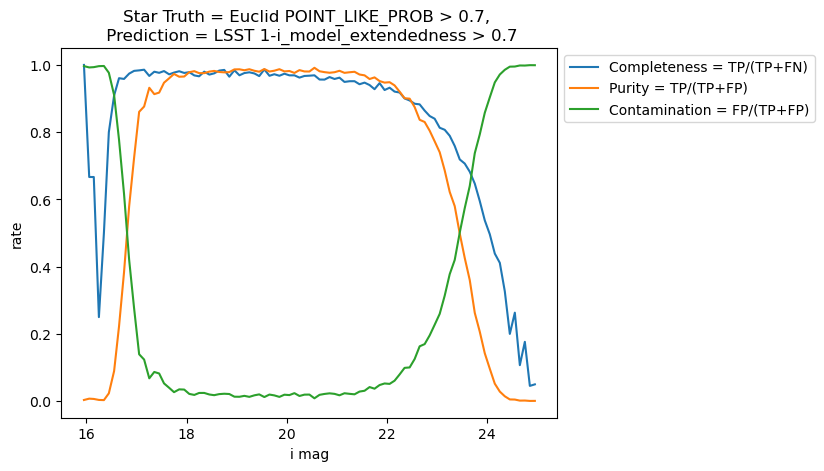

In [19]:
## create magnitude range chunks
threshold = 0.7

i_mags = []
completenesses = []
puritys = []
contaminations = []
for i_mag in np.arange(16,26,0.1):
    mag_bin_mask = (DF_magcut.i_mag >= (i_mag - 0.1)) & (DF_magcut.i_mag <= (i_mag))
    data_binned = DF_magcut.apply_mask(mag_bin_mask) #data_binned is a DataFrame object
    if len(data_binned.data)>0:
        lsst_predicted_clean, mask = lsst_predicted(data_binned, threshold)
        #print(threshold)
        euclid_truth_clean = euclid_truth(data_binned)[mask]
        
        #tns, fps, fns, tps, thresholds = confusion_matrix_at_thresholds(euclid_truth_clean, lsst_predicted_clean)
        #fpr, tpr, thresholds = roc_curve(euclid_truth_clean, lsst_predicted_clean)
        
        tn, fp, fn, tp = confusion_matrix(euclid_truth_clean, lsst_predicted_clean, labels=[0,1]).ravel().tolist()
        total = len(lsst_predicted_clean)
    
        completeness = tp/(tp+fn) #true positive rate
        purity = tp/(tp+fp) #positive predictive value
        contamination = fp/(tp+fp) #false discovery rate
        if not np.isclose(purity - 1 + contamination, 0):
            print("Alarm! PPV != 1- FDR")

        i_mags.append(np.median(data_binned.i_mag))
        completenesses.append(completeness)
        puritys.append(purity)
        contaminations.append(contamination)

        #plt.plot(data_binned.i_mag,np.linspace(completeness,completeness,len(data_binned.i_mag)),c='b')
        #plt.plot(data_binned.i_mag,np.linspace(purity,purity,len(data_binned.i_mag)),c='g')
plt.title(f'Star Truth = Euclid POINT_LIKE_PROB > 0.7, \n Prediction = LSST 1-i_model_extendedness > {threshold}')
plt.plot(i_mags, completenesses, label='Completeness = TP/(TP+FN)')
plt.plot(i_mags, puritys, label='Purity = TP/(TP+FP)')
plt.plot(i_mags, contaminations, label='Contamination = FP/(TP+FP)')
plt.ylabel('rate')
plt.xlabel('i mag')
plt.legend(bbox_to_anchor = (1,1))
plt.show()

In [ ]:
# confusion matrix: https://en.wikipedia.org/wiki/Confusion_matrix#Table_of_confusion